In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
paths = ['linear','sequential','graph','mixed']

### Predictions Distribution

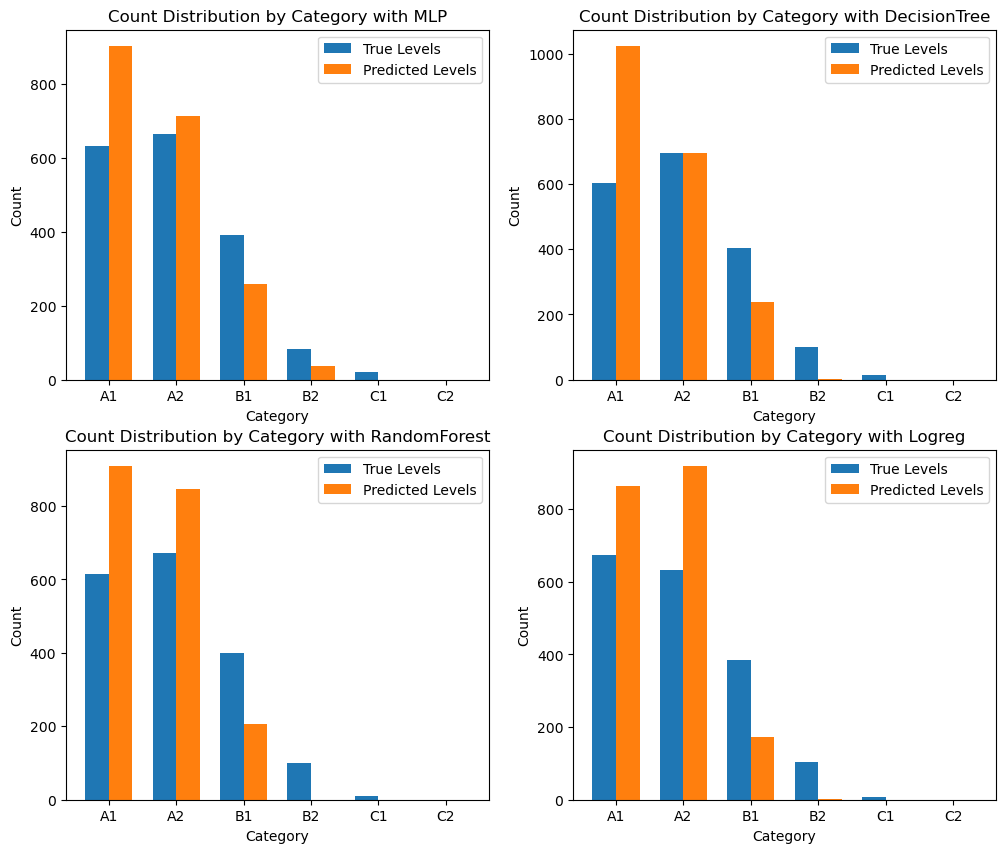

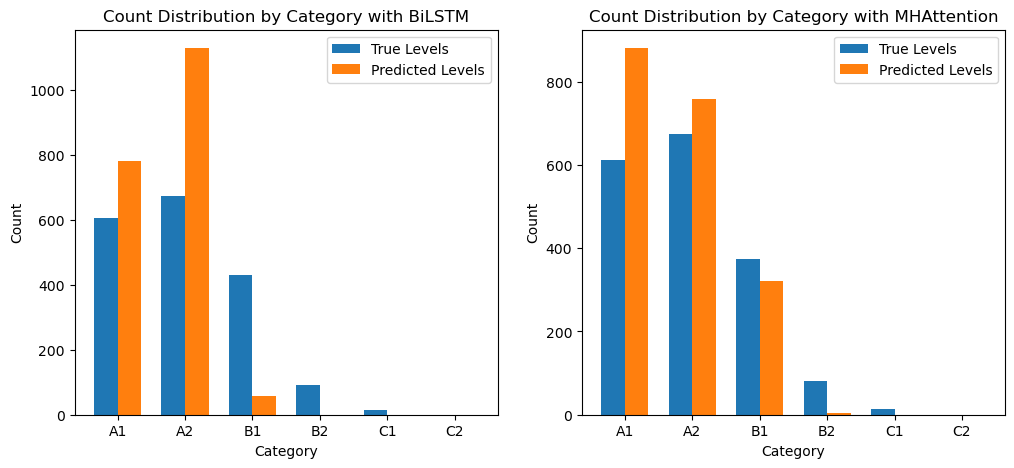

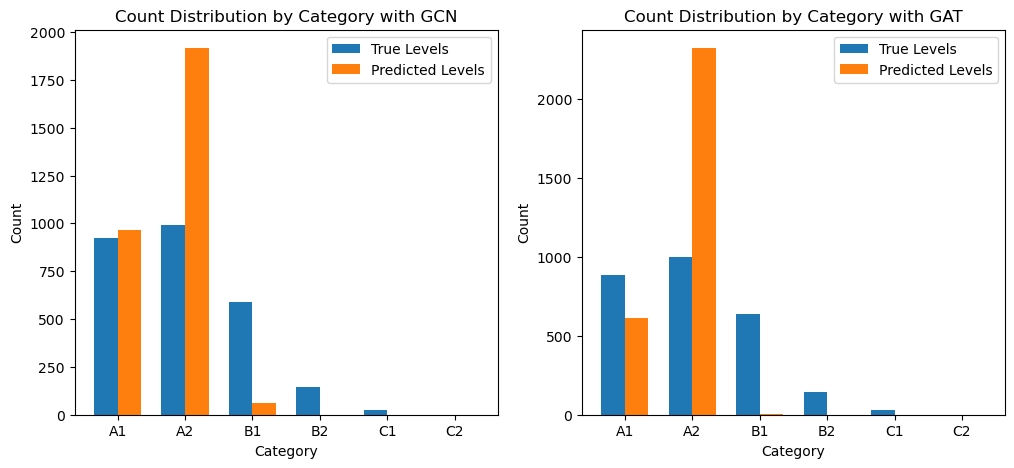

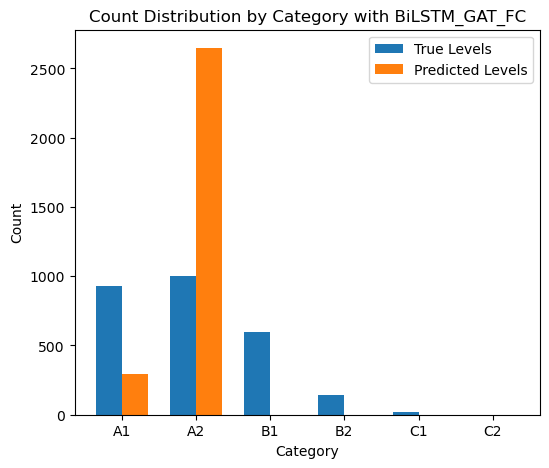

In [3]:
for path in paths:
    quantitative_df = pd.read_csv(path+'.csv')
    model_names = quantitative_df['name'].unique()
    n_models = len(model_names)
    # choose layout
    if n_models <= 2:
        fig, axes = plt.subplots(1, max(n_models, 1), figsize=(6 * max(n_models, 1), 5))
    else:  # e.g., 3 or 4 models
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    # flatten axes and ensure iterable
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
    for ax, model_name in zip(axes, model_names):
        plt.sca(ax)
        y_true = quantitative_df[quantitative_df['name']==model_name]['y_true']
        y_pred = quantitative_df[quantitative_df['name']==model_name]['y_pred']
        bins = np.arange(1, 7)
        labels = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
        counts_true = [np.sum(y_true == i) for i in bins]
        counts_pred = [np.sum(y_pred == i) for i in bins]
        width = 0.35
        plt.bar(bins - width/2, counts_true, width=width, label='True Levels')
        plt.bar(bins + width/2, counts_pred, width=width, label='Predicted Levels')
        plt.xlabel('Category')
        plt.ylabel('Count')
        plt.title(f'Count Distribution by Category with {model_name}')
        plt.xticks(bins, labels)
        plt.legend()
    
    # hide any extra axes if layout bigger than number of models
    for ax in axes[n_models:]:
        ax.set_visible(False)
    plt.savefig(path+'_plot.jpeg')

### Other Metrics

In [23]:
from sklearn.metrics import accuracy_score,root_mean_squared_error,f1_score

In [26]:
def band_score(y_true,y_pred): 
    y_true = y_true//2
    y_pred = y_pred //2
    return accuracy_score(y_true,y_pred),f1_score(y_true,y_pred,average='macro')

In [30]:
all_metrics = []

for path in paths:
    quantitative_df = pd.read_csv(path+'.csv')
    model_names = quantitative_df['name'].unique()
    for model_name in model_names:
        y_true = quantitative_df[quantitative_df['name']==model_name]['y_true']
        y_pred = quantitative_df[quantitative_df['name']==model_name]['y_pred']
        metrics_dict = {
            'Model Class': path,
            'Model Name': model_name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'RMSE': root_mean_squared_error(y_true, y_pred),
            'Band Accuracy': band_score(y_true, y_pred)[0],
            'Band F1': band_score(y_true, y_pred)[1]
        }
        
        all_metrics.append(metrics_dict)
metrics_df = pd.DataFrame(all_metrics)

# Optional: save to CSV
metrics_df.to_csv('extended_model_metrics.csv', index=False)

In [31]:
metrics_df

,Model Class,Model Name,Accuracy,RMSE,Band Accuracy,Band F1
0,linear,MLP,0.389796,1.086090,0.588265,0.450365
1,linear,DecisionTree,0.384184,1.145978,0.568367,0.394952
2,linear,RandomForest,0.391837,1.025442,0.596939,0.407362
3,linear,Logreg,0.405612,1.035591,0.605102,0.414017
4,sequential,BiLSTM,0.334010,1.159161,0.512690,0.339887
5,sequential,MHAttention,0.395939,0.962495,0.647208,0.441483
6,graph,GCN,0.330952,1.132843,0.513265,0.334950
7,graph,GAT,0.324150,1.135542,0.513946,0.302076
8,mixed,BiLSTM_GAT_FC,0.337755,1.084993,0.529932,0.279448


# Most Important Features for Linear Models

## MLPClassifier
**Top 5 Most Important Features:**
1. **Language_exposure** : 0.013265  
2. **Domain_of_specialization_Medecine** : 0.010204  
3. **Domain_of_specialization_Information Communication** : 0.009184  
4. **Stay_duration_weeks** : 0.007143  
5. **Other_language_Aucune** : 0.004592  

---

## DecisionTreeClassifier
**Top 5 Most Important Features:**
1. **Reinforced_section_0** : 0.026020  
2. **Domain_of_specialization_Medecine** : 0.014286  
3. **Reading_frequency_jamais** : 0.013265  
4. **Language_exposure** : 0.009184  
5. **Years_studying_L2** : 0.005102  

---

##  RandomForestClassifier
**Top 5 Most Important Features:**
1. **Domain_of_specialization_Medecine** : 0.010714  
2. **Domain_of_specialization_Information Communication** : 0.009694  
3. **Domain_of_specialization_Sciences de la vie et de l'environnement** : 0.007143  
4. **Other_language_Espagnol** : 0.006633  
5. **Domain_of_specialization_Informatique et electronique** : 0.006122  

---

##  LogisticRegression
**Top 5 Most Important Features:**
1. **Reinforced_section_0** : 0.028061  
2. **Domain_of_specialization_Informatique et electronique** : 0.026020  
3. **Reading_frequency_quotidienne** : 0.020918  
4. **Language_exposure** : 0.017857  
5. **Domain_of_specialization_Information Communication** : 0.016837  

## Graph Size When varying columns parameters

In [34]:
data_path = '/home/mati/uni/Wise_25/opinion_sent/proficiency/data/data.csv'

In [35]:
dataset = pd.read_csv(data_path)

In [ ]:
columns_categorical = ["L1", "Domain_of_specialization", "Reading_frequency", "Other_language"]
columns_binary = ["Reinforced_section"]
columns_numerical = ["Years_studying_L2", "Stay_duration_weeks", "Stay_frequency", "Language_exposure"]
params_dict = {'GCN' : {'threshold': 0.9,'graph_columns': [
        "Years_studying_L2",
       "Reinforced_section",
        "Language_exposure",
        "Reading_frequency"
      ],'GAT': {'threshold':0.9,'graph_columns': [
        "Years_studying_L2",
       "Reinforced_section",
        "Language_exposure",
        "Reading_frequency",]}}}

In [ ]:


n_examples = dataset.shape[0]
n_features = len(graph_columns)
adjacency = np.zeros((n_examples, n_examples))
for column in graph_columns:
    values = dataset[column].values
    if column in columns_categorical or column in columns_binary:
        adjacency += (values[:, None] == values[None, :]).astype(float)
    elif column in columns_numerical:
        adjacency += 1 / (1 + np.abs(values[:, None] - values[None, :]))
np.fill_diagonal(adjacency, 0)
adjacency = adjacency / n_features
adjacency[adjacency < threshold] = 0
